In [365]:
import pandas as pd
import pickle as pkl
import json
from credit_risk_classifier.paths import DATA_PATH
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [54]:
# load in test data
with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df = pkl.load(f)

In [28]:
# load in the model - just use XGBOost for now
with open('../models/XGBoost.pkl', 'rb') as f:
    model = pkl.load(f)

In [225]:
with open('../data/processed/mean_std_per_client.json', 'r') as f:
    df_std_mean_usage = pd.read_json(f).T
    # create dictionary version for fast lookup
    dict_std_mean_usage = df_std_mean_usage.to_dict(orient='index')

In [350]:
# for now get one client

client_to_pick = 277
df_one_client = df[df.index.get_level_values('client_id') == client_to_pick]

X_test = df_one_client.drop(columns=['hourly_usage_kwh'])
y_test = df_one_client['hourly_usage_kwh']

In [349]:
df.index.get_level_values('client_id').unique()

Index([ 16,  21,  23,  24,  25,  27,  28,  35,  36,  44,  49,  51,  53,  55,
        60,  62,  65,  75,  80,  84, 101, 103, 104, 114, 119, 123, 124, 125,
       128, 132, 136, 139, 141, 145, 147, 149, 150, 151, 156, 161, 164, 165,
       166, 167, 170, 172, 182, 185, 194, 195, 200, 204, 206, 209, 210, 217,
       219, 222, 225, 229, 231, 235, 238, 239, 240, 241, 245, 247, 249, 250,
       253, 254, 255, 262, 268, 269, 272, 277, 281, 282, 293, 296, 300, 301,
       303, 304, 307, 317, 319, 321, 324, 327, 328, 329, 330, 336, 343, 354,
       366, 370],
      dtype='int64', name='client_id')

In [ ]:
# want a 24 hour forecast, produced at 6am each day (in future could do more regularly)

# for each 6 am time point (starting 1 month into test data so have data to compute the rolling stats)
#   first obtain the staistics using the target values (i.e., from y test)
#   predict next timestep, append to a list (which can then put into df)
#   then use to create features for the next timestep (update the lag and rolling features when required)
#   then make prediction and repeat until forecasted up to the day at that time
#   use index of time point (hour of day) to know how much to index into test data vs predictions to get the 
#   rolling/lag stats

#   track day number (and day itself) as well as hour number

In [351]:
# get datetimes at 6am
datetimes = y_test.index.get_level_values('datetime')
datetimes_forecast_start = datetimes[datetimes.hour == 6]

In [352]:
# forecast horizon of 24 hours
HORIZON = 24
# create empty list for predicted usage
y_preds = []

In [353]:
def update_the_feature_series(initial_features_index, day_index, hour_index, datetime):
    """ creates a new feature series for a given time point, given 
    how far through the recursive forecast the prediction is being made  """


    # get row from test feature set corresponding to this datetime (to extract datetime features)
    # for the time features (double bracket index turns into a frame)
    feature_series = X_test.iloc[[initial_features_index + hour_index]]

    #############
    # get hourly usage data in context window

    # for target data to get want 1 month after the current time point, 
    # up to to most recent data acquired
    data_from_target = y_test.iloc[initial_features_index + hour_index - 168: initial_features_index].to_list()
    # print(y_test.iloc[initial_features_index + hour_index - 168: initial_features_index])
    # then get data from preds
    data_from_preds = y_preds[day_index*24: day_index*24 + hour_index]
        
    # and combine into an array
    data_to_process = np.array((data_from_target + data_from_preds))

    if len(data_to_process) != 168:
        print('\n current day index: ', day_index)
        print('\n current hour index: ', hour_index)
        print('\n initial features index: ', initial_features_index)
        print("\n length data from preds: \n", len(data_from_preds))
        print("\n length data from target: \n", len(data_from_target))
        raise Exception(f'length of context window is {len(data_to_process)}, should be 168')

    # get lag features
    feature_series['lag_1hr'] = data_to_process[-1]
    feature_series['lag_2hr'] = data_to_process[-2]
    feature_series['lag_6hr'] = data_to_process[-6]
    feature_series['lag_1dy'] = data_to_process[-24]
    feature_series['lag_1wk'] = data_to_process[-168]

    # compute the rolling features
    feature_series['rolling_mean_1dy'] = np.mean(data_to_process[-24:])
    feature_series['rolling_mean_1wk'] = np.mean(data_to_process[-168:])

    feature_series['rolling_max_1dy'] = np.max(data_to_process[-24:])
    feature_series['rolling_max_1wk'] = np.max(data_to_process[-168:])

    feature_series['rolling_min_1dy'] = np.min(data_to_process[-24:])
    feature_series['rolling_min_1wk'] = np.min(data_to_process[-168:])

    feature_series['rolling_std_1dy'] = np.std(data_to_process[-24:])
    feature_series['rolling_std_1wk'] = np.std(data_to_process[-168:])

    return feature_series

In [354]:
# TODO: eventually figure out way to avoid nested loops

# NOTE: skipping the first month here because thats where have lag data in test data in current setup
# (28 6 hour points in first month), then looping up to second to last value, which is last value where full 24 hour cycle is present 
for day_num, datetime in enumerate(datetimes_forecast_start[28:-1]):

    # get the index corresponding to initial features
    initial_features_index = X_test.index.get_loc((client_to_pick, datetime))
    
    # then loop through the forecast horizon
    for hour_index in range(HORIZON):

        # if hour index is zero, use the exact same features as in test data set
        if hour_index == 0:
            feature_series = X_test.iloc[[initial_features_index]]
        else:
            # otherwise recompute the features using prediction data
            feature_series = update_the_feature_series(initial_features_index=initial_features_index, 
                                                    day_index=day_num, 
                                                    hour_index=hour_index, datetime=datetime)
        
        # get the prediction for that hour
        pred = model.predict(feature_series)
        # append the prediction to the preds list
        y_preds.append(float(pred[0]))

In [355]:
# create datetime array for the datetimes that predictions are for
datetimes_preds = pd.date_range(datetimes_forecast_start[28], datetimes_forecast_start[-1] - pd.Timedelta('1 hour'), freq='h')

In [356]:
# create dataframe for predictions
y_preds_df = pd.DataFrame(data=y_preds, index=datetimes_preds, columns=['y_pred'])

In [357]:
# filter into testing data to get actual values
y_preds_df['y_label'] = y_test[y_test.index.get_level_values('datetime').isin(datetimes_preds)].droplevel('client_id')

In [358]:
# unscale the target and predictions

y_preds_df = y_preds_df * dict_std_mean_usage[client_to_pick]['std'] + dict_std_mean_usage[client_to_pick]['mean']

In [359]:
# compute the NRMSE for each hour
y_preds_df.index.name = 'datetime'

rmse_each_hour = y_preds_df.groupby(datetimes_preds.hour).apply(lambda g: root_mean_squared_error(y_true=g['y_label'], y_pred=g['y_pred']))

In [374]:
nrmse_per_hour = rmse_each_hour/dict_std_mean_usage[client_to_pick]['mean']
nrmse_per_hour

datetime
0     0.052590
1     0.050413
2     0.056875
3     0.047579
4     0.040976
5     0.040658
6     0.053297
7     0.055502
8     0.054449
9     0.053346
10    0.051333
11    0.055430
12    0.058504
13    0.062114
14    0.064469
15    0.065820
16    0.068713
17    0.071065
18    0.074996
19    0.069697
20    0.067145
21    0.070365
22    0.072018
23    0.062195
dtype: float64

In [361]:
# get predictions from single timestep prediction
y_preds_single_step = model.predict(X_test[X_test.index.get_level_values('datetime').isin(datetimes_preds)])

# unscale the predcition
y_preds_single_step_unscaled = y_preds_single_step * dict_std_mean_usage[client_to_pick]['std'] + dict_std_mean_usage[client_to_pick]['mean']

In [362]:
df_single_preds = pd.DataFrame(data={'y_pred': y_preds_single_step_unscaled, 'y_label': y_preds_df['y_label']}, index=y_preds_df.index)

In [363]:
# and compute rmse per hour again
rmse_each_hour_single = df_single_preds.groupby(datetimes_preds.hour).apply(lambda g: root_mean_squared_error(y_true=g['y_label'], y_pred=g['y_pred']))

In [364]:
nrmse_each_hour_single = rmse_each_hour_single / dict_std_mean_usage[client_to_pick]['mean']

nrmse_each_hour_single

datetime
0     0.043081
1     0.037421
2     0.033580
3     0.019255
4     0.024037
5     0.015806
6     0.053297
7     0.050616
8     0.051241
9     0.045835
10    0.041906
11    0.044402
12    0.044133
13    0.044849
14    0.045005
15    0.045154
16    0.044453
17    0.045885
18    0.050491
19    0.034355
20    0.040574
21    0.039395
22    0.042828
23    0.063380
dtype: float64

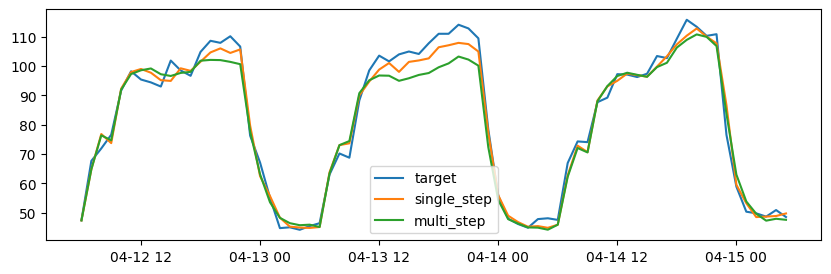

In [372]:
datetimes_to_plot = datetimes_preds[:72]


plt.figure(figsize=(10, 3))
plt.plot(datetimes_to_plot, df_single_preds['y_label'].iloc[:72], label='target')
plt.plot(datetimes_to_plot, df_single_preds['y_pred'].iloc[:72], label='single_step')
plt.plot(datetimes_to_plot, y_preds_df['y_pred'].iloc[:72], label='multi_step')
plt.legend()
plt.show()